### 🤖 Implement ReAct with LangGraph-What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

### Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

#### ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [5]:
import os
from dotenv import load_dotenv

from typing import Annotated, Sequence, TypedDict
from langchain.tools import tool
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader, ArxivLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain.agents import create_agent
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_community.document_loaders import TextLoader
from langchain.chat_models import init_chat_model


load_dotenv()


True

In [6]:
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm=init_chat_model("gpt-5.4-nano")
llm

ChatOpenAI(output_version=None, profile={'name': 'GPT-5.4 nano', 'release_date': '2026-03-17', 'last_updated': '2026-03-17', 'open_weights': False, 'max_input_tokens': 400000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7bcb1182bb60>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7bcb1159c6e0>, root_client=<openai.OpenAI object at 0x7bcb11f7c590>, root_async_client=<openai.AsyncOpenAI object at 0x7bcb1159c440>, model_name='gpt-5.4-nano', model_kwargs={}, openai_api_ke

In [27]:
### Generic function to create a retireval tool
def make_retriever_tool_from_text(file,name,desc):
    """Use this function to create documents from files"""
    docs=TextLoader(file,encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vs.as_retriever()

    @tool(name, description=desc)
    def tool_func(query:str)->str:
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return tool_func


# Wikipedia Tool
@tool
def wiki_tool(): 
    """Use this tool to fetch general world knowledge from Wikipedia."""
    print(f"Using Wikipedia Tool")
    return WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())


# ArXiv Tool
@tool
def arxiv_search(query: str) -> str:
    """Use this tool to fetch recent academic papers on technical topics."""
    print("🧪 Searching ArXiv...")
    results = ArxivLoader(query, load_max_docs=2).load()
    return "\n\n".join(doc.page_content[:1000] for doc in results[:2]) or "No papers found."


In [28]:
internal_tool_1=make_retriever_tool_from_text(
    "internal_docs.txt",
    "Internal_tech_docs",
    "Search internal tech documents for proprietary architecture and methods."
)
internal_tool_1

StructuredTool(name='Internal_tech_docs', description='Search internal tech documents for proprietary architecture and methods.', args_schema=<class 'langchain_core.utils.pydantic.Internal_tech_docs'>, func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x7bcb10b785c0>)

In [29]:
internal_tool_2 = make_retriever_tool_from_text(
    "research_notes.txt",
    "Internal_research_notes",
    "Search internal research notes for experimental results and agent designs."
)
internal_tool_2

StructuredTool(name='Internal_research_notes', description='Search internal research notes for experimental results and agent designs.', args_schema=<class 'langchain_core.utils.pydantic.Internal_research_notes'>, func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x7bcb10b7a2a0>)

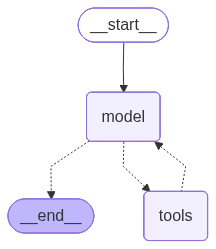

In [30]:
tools=[wiki_tool,arxiv_search,internal_tool_1,internal_tool_2]

react_node=create_agent(llm,tools)
react_node

In [31]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

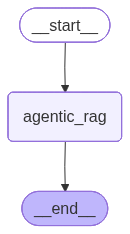

In [32]:
builder = StateGraph(AgentState)
builder.add_node("agentic_rag", react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag", END)

graph = builder.compile()
graph


In [ ]:
query = "What do our internal research notes say about agent loop, and what does ArXiv suggest recently?"

state = {"messages": [HumanMessage(content=query)]}
result = graph.invoke(state)

print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using tool: Internal_research_notes
🧪 Searching ArXiv...
